# **ChatGPT Reviews** **Analysis**


## Project Objective

This project analyzes customer reviews of ChatGPT to understand user
satisfaction, sentiment, and the specific features or aspects users
frequently praise or criticize.

The analysis uses exploratory data analysis, natural language processing,
sentiment analysis, keyword extraction, phrase analysis, and data
visualization.

### Key Questions

1. What is the overall sentiment of ChatGPT users?
2. How strong and subjective are user sentiments?
3. How are numerical ratings distributed?
4. Are ratings consistent with textual sentiment?
5. What features do users appreciate most?
6. What problems do users mention most frequently?
7. How does review activity change over time?
8. Does sentiment change over time?

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

from textblob import TextBlob

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 11

## 1. Data Understanding

First, we load the ChatGPT review dataset and inspect its structure,
dimensions, columns, data types, and initial records.

In [19]:
from google.colab import files

uploaded = files.upload()

Saving chatgpt_reviews.csv to chatgpt_reviews (1).csv


In [20]:
df = pd.read_csv("chatgpt_reviews.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 196727
Columns: 4


### Standardize Column Names

In [21]:
#Inspect Dataset
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [22]:
df.tail()

,Review Id,Review,Ratings,Review Date
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,2023-07-27 16:26:31
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,2023-09-23 16:25:18
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,2023-11-08 13:57:14
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,2023-07-25 15:32:57
196726,0151001d-b81c-41b5-8927-f56738989625,expert application,5,2023-11-30 18:11:41


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [24]:
print("Column Names:")

for column in df.columns:
    print(column)

Column Names:
Review Id
Review
Ratings
Review Date


In [25]:
#Standardize Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['review_id', 'review', 'ratings', 'review_date']


In [26]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (
        df.isnull().mean() * 100
    ).round(2)
})

missing_values

,Missing Values,Percentage
review_id,0,0.0
review,6,0.0
ratings,0,0.0
review_date,0,0.0


In [27]:
#Handle Missing Reviews
df['review'] = df['review'].fillna('')

In [28]:
print(
    "Missing reviews:",
    df['review'].isnull().sum()
)

Missing reviews: 0


In [30]:
#Convert Data Types

df['ratings'] = pd.to_numeric(
    df['ratings'],
    errors='coerce'
)

df['review_date'] = pd.to_datetime(
    df['review_date'],
    errors='coerce'
)

In [32]:
print(df.dtypes)

review_id              object
review                 object
ratings                 int64
review_date    datetime64[ns]
dtype: object


In [33]:
#Check Duplicates

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate Review IDs:",
    df['review_id'].duplicated().sum()
)

Duplicate rows: 2511
Duplicate Review IDs: 3573


In [34]:
df = df.drop_duplicates().reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (194216, 4)


In [35]:
#Rating Validation
print(
    "Unique Ratings:",
    sorted(df['ratings'].dropna().unique())
)

Unique Ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [37]:
print(
    df['ratings']
    .value_counts()
    .sort_index()
)

ratings
1     11966
2      3346
3      8046
4     22603
5    148255
Name: count, dtype: int64


## 2. Feature Engineering

Additional variables are created from the review text and review date
to support exploratory analysis.

In [38]:
df['review_length'] = (
    df['review']
    .astype(str)
    .str.len()
)

In [39]:
df['word_count'] = (
    df['review']
    .astype(str)
    .str.split()
    .str.len()
)

In [41]:
df['year'] = df['review_date'].dt.year

df['month'] = df['review_date'].dt.month

df['month_name'] = (
    df['review_date']
    .dt.month_name()
)

df['day_name'] = (
    df['review_date']
    .dt.day_name()
)

In [42]:
df[['review', 'review_length', 'word_count']].head()

,review,review_length,word_count
0,good,4,1
1,good,4,1
2,nice app,8,2
3,"nice, ig",8,2
4,"this is a great app, the bot is so accurate to...",368,67


In [44]:
#Basic Statistics
df.describe()

,ratings,review_date,review_length,word_count,year,month
count,194216.000000,194216,194216.000000,194216.000000,194216.000000,194216.000000
mean,4.502631,2024-03-25 06:32:37.295047936,46.776131,8.768521,2023.754938,6.200879
min,1.000000,2023-07-25 15:01:35,0.000000,0.000000,2023.000000,1.000000
25%,5.000000,2024-01-04 09:09:33,9.000000,2.000000,2024.000000,4.000000
50%,5.000000,2024-04-21 09:48:35.500000,18.000000,4.000000,2024.000000,6.000000
75%,5.000000,2024-06-26 14:20:45,50.000000,10.000000,2024.000000,8.000000
max,5.000000,2024-08-23 19:30:05,500.000000,134.000000,2024.000000,12.000000
std,1.084235,NaN,75.246641,13.575902,0.430125,2.794520


In [45]:
print("Total Reviews:", len(df))

print(
    "Average Rating:",
    round(df['ratings'].mean(), 2)
)

print(
    "Median Rating:",
    df['ratings'].median()
)

print(
    "Average Review Words:",
    round(df['word_count'].mean(), 2)
)

print(
    "Average Review Characters:",
    round(df['review_length'].mean(), 2)
)

Total Reviews: 194216
Average Rating: 4.5
Median Rating: 5.0
Average Review Words: 8.77
Average Review Characters: 46.78


# 3. Exploratory Data Analysis

## Rating Distribution

The rating distribution helps understand overall user satisfaction
before performing textual sentiment analysis.

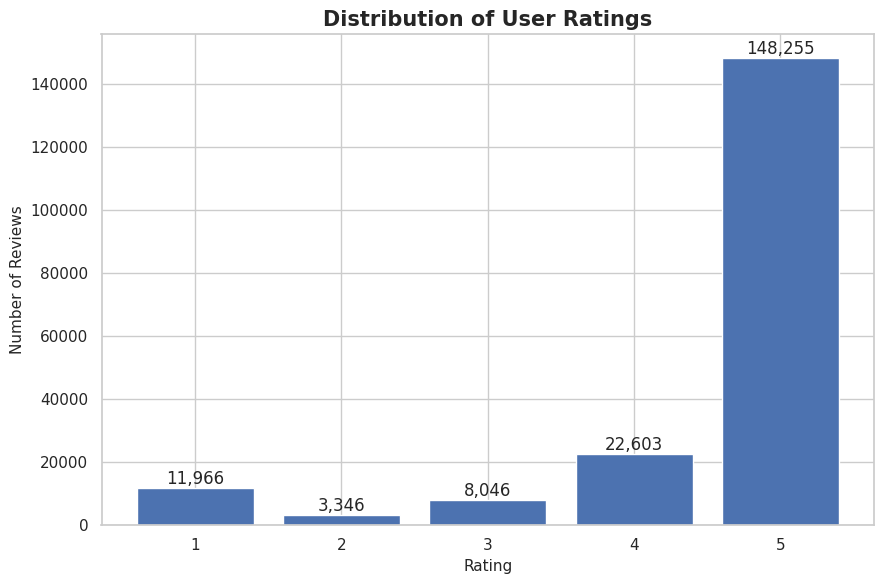

In [46]:
rating_counts = (
    df['ratings']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title(
    'Distribution of User Ratings',
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

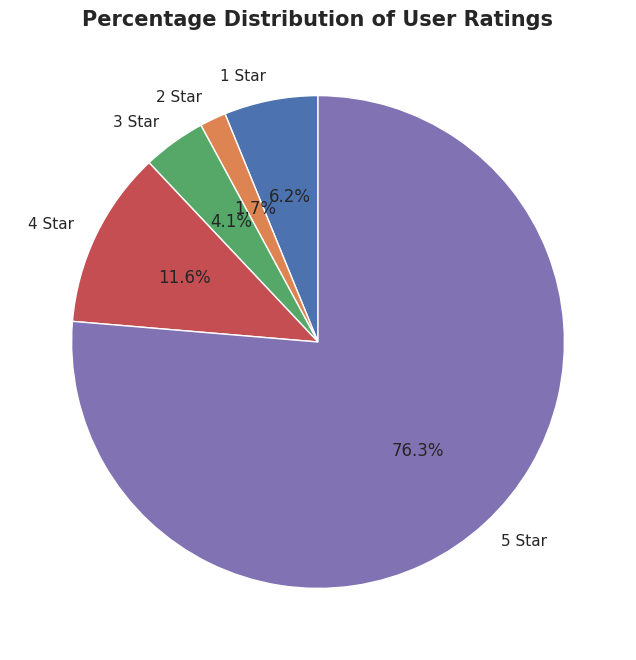

In [47]:
#Rating Percentage
rating_percentage = (
    df['ratings']
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(8, 8))

plt.pie(
    rating_percentage.values,
    labels=[
        f'{x} Star'
        for x in rating_percentage.index
    ],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Percentage Distribution of User Ratings',
    fontweight='bold'
)

plt.show()

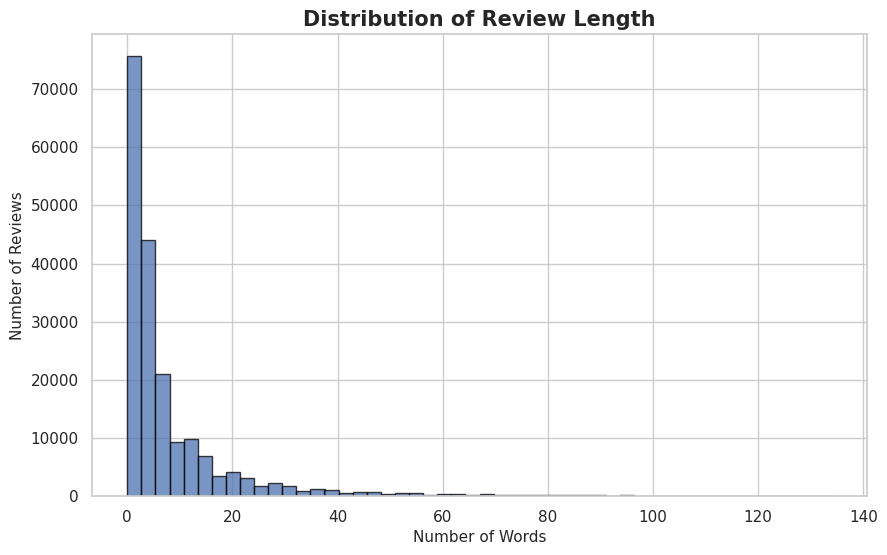

In [48]:
#Review Length Distribution
plt.figure(figsize=(10, 6))

plt.hist(
    df['word_count'],
    bins=50,
    edgecolor='black',
    alpha=0.75
)

plt.title(
    'Distribution of Review Length',
    fontweight='bold'
)

plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')

plt.show()

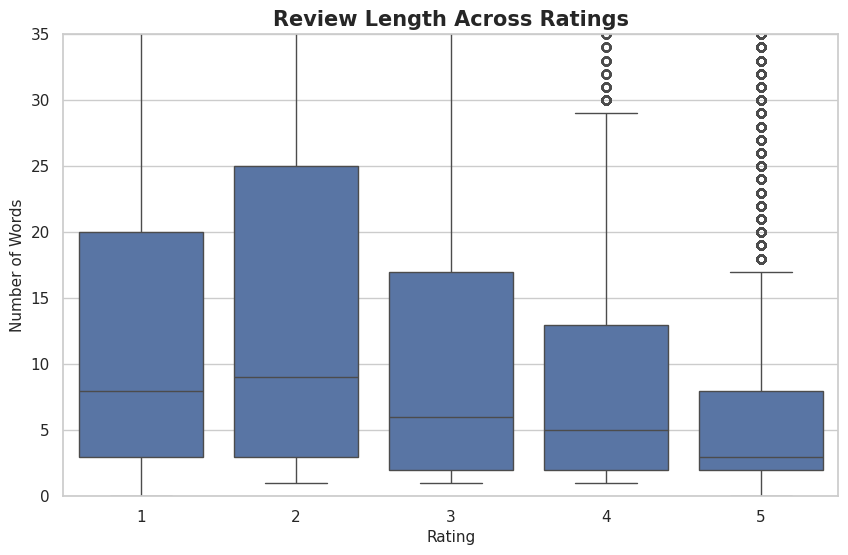

In [49]:
#Review Length by Rating
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='ratings',
    y='word_count'
)

plt.title(
    'Review Length Across Ratings',
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Number of Words')

plt.ylim(
    0,
    df['word_count'].quantile(0.95)
)

plt.show()

In [51]:
#Reviews Over Time
monthly_reviews = (
    df.groupby(
        df['review_date'].dt.to_period('M')
    )
    .size()
)

monthly_reviews.index = (
    monthly_reviews.index.to_timestamp()
)

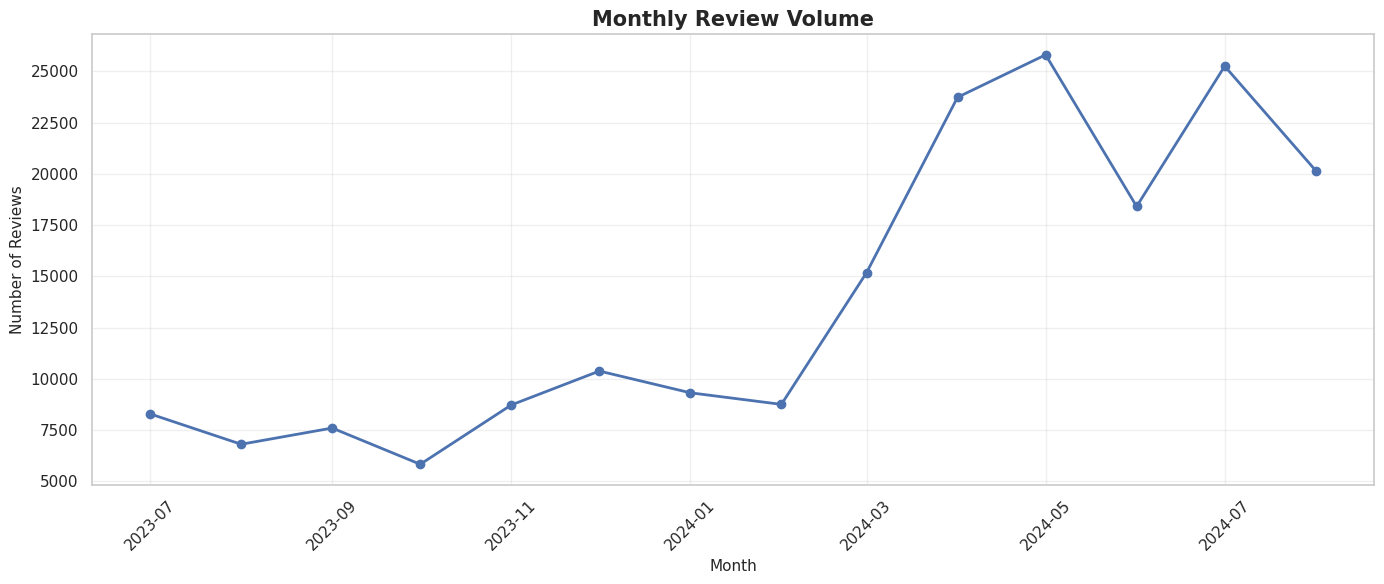

In [52]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_reviews.index,
    monthly_reviews.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Monthly Review Volume',
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
#Average Rating Over Time
monthly_rating = (
    df.groupby(
        df['review_date'].dt.to_period('M')
    )['ratings']
    .mean()
)

monthly_rating.index = (
    monthly_rating.index.to_timestamp()
)

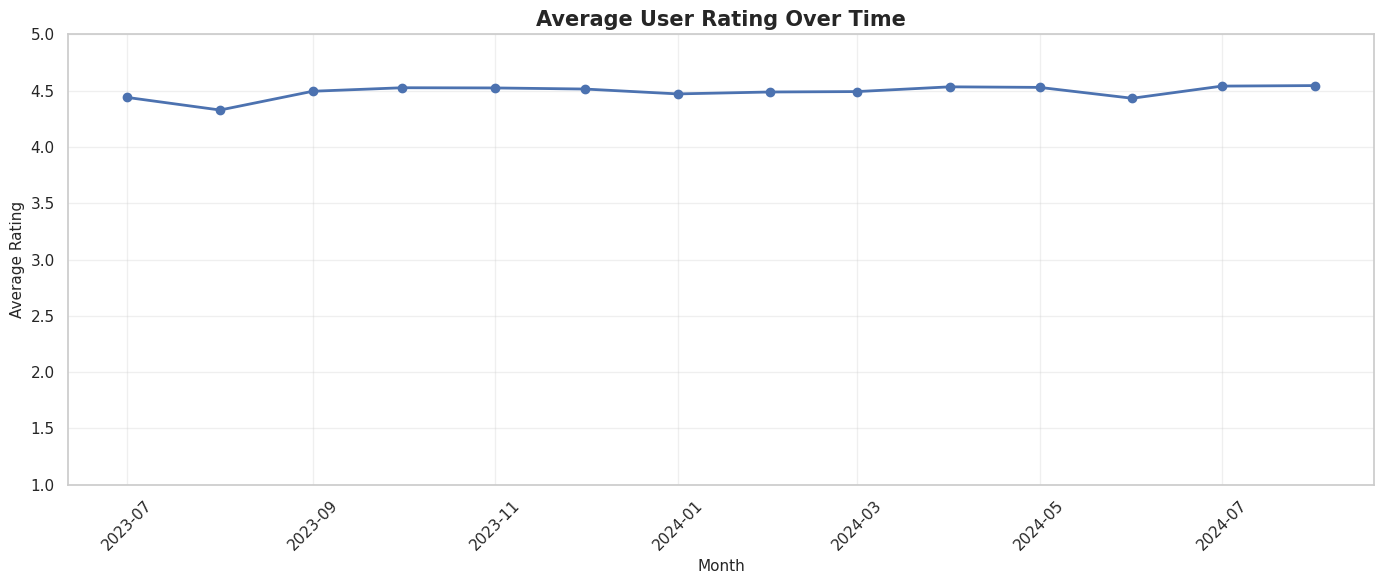

In [54]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_rating.index,
    monthly_rating.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Average User Rating Over Time',
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Average Rating')

plt.ylim(1, 5)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
#Day-of-Week Analysis

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_counts = (
    df['day_name']
    .value_counts()
    .reindex(day_order)
)

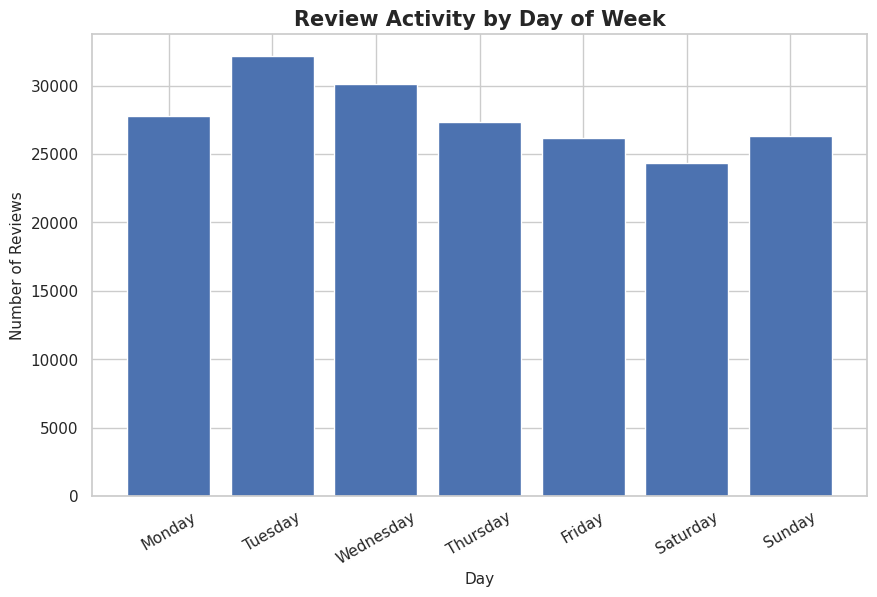

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    day_counts.index,
    day_counts.values
)

plt.title(
    'Review Activity by Day of Week',
    fontweight='bold'
)

plt.xlabel('Day')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=30)

plt.show()

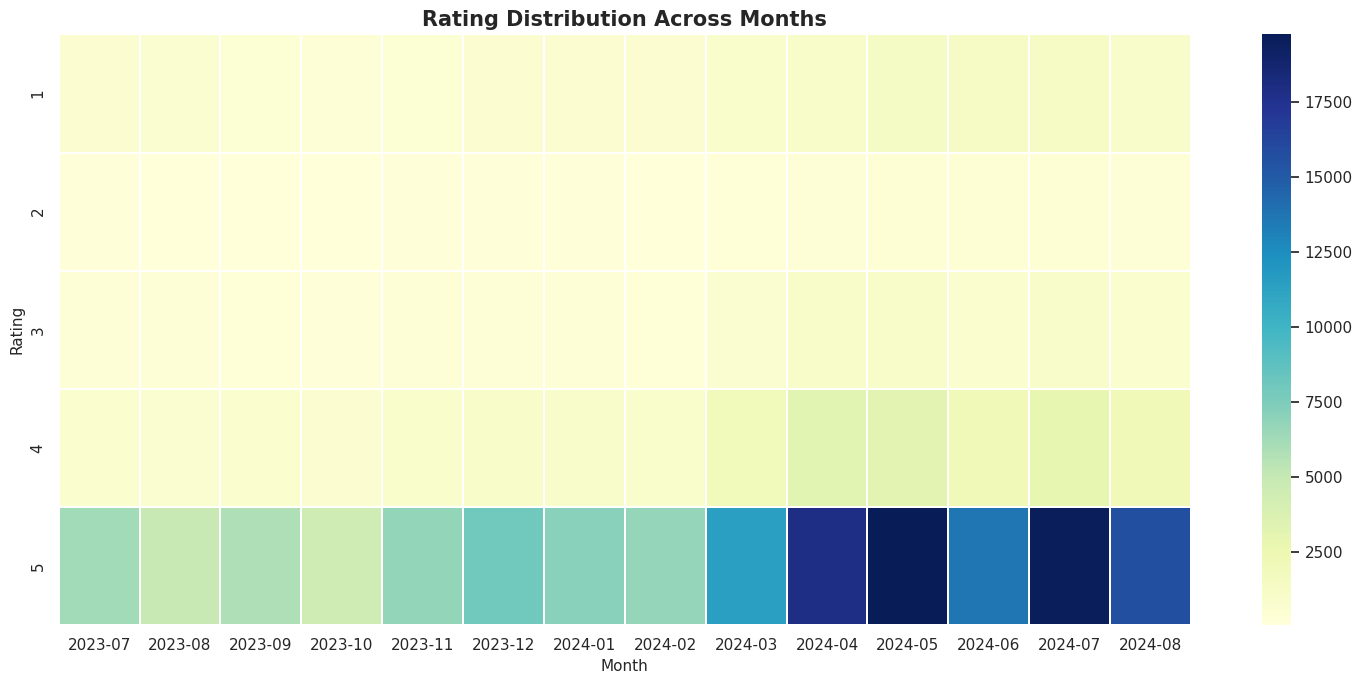

In [60]:
#Rating Heatmap

rating_month = pd.crosstab(
    df['review_date'].dt.to_period('M'),
    df['ratings']
)

plt.figure(figsize=(15, 7))

sns.heatmap(
    rating_month.T,
    cmap='YlGnBu',
    linewidths=0.2
)

plt.title(
    'Rating Distribution Across Months',
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

# 4. Text Analysis

The review text is cleaned before performing keyword extraction and
sentiment analysis.

In [61]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


df['clean_review'] = (
    df['review']
    .apply(clean_text)
)

In [63]:
#Most Common Words
all_words = []

for review in df['clean_review']:

    all_words.extend(
        review.split()
    )

print(
    "Total words:",
    len(all_words)
)

Total words: 1688729


In [65]:
#Remove Stop Words
stop_words = {
    'the', 'and', 'this', 'that',
    'with', 'for', 'you', 'are',
    'was', 'have', 'has', 'but',
    'not', 'they', 'its', 'from',
    'can', 'very', 'just', 'use',
    'using', 'chat', 'gpt',
    'app', 'get', 'like',
    'one', 'would', 'also',
    'really', 'much'
}

filtered_words = [
    word
    for word in all_words
    if len(word) >= 3
    and word not in stop_words
]

In [66]:
#Top 20 Words
word_frequency = Counter(
    filtered_words
)

top_words = (
    word_frequency
    .most_common(20)
)

top_words

[('good', 39343),
 ('best', 18233),
 ('nice', 13777),
 ('great', 11923),
 ('helpful', 11569),
 ('chatgpt', 10379),
 ('amazing', 8707),
 ('love', 8652),
 ('useful', 7608),
 ('all', 6397),
 ('excellent', 6160),
 ('awesome', 5090),
 ('more', 5006),
 ('work', 4386),
 ('help', 4262),
 ('information', 4221),
 ('ever', 4141),
 ('answer', 4072),
 ('time', 3924),
 ('when', 3858)]

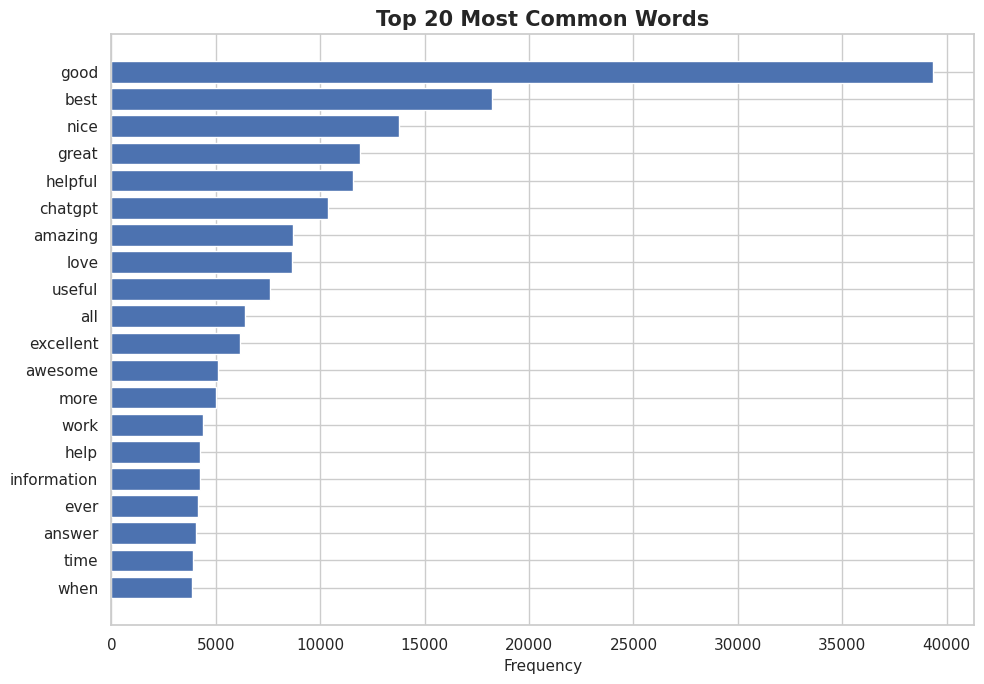

In [67]:
words = [
    x[0]
    for x in top_words
]

counts = [
    x[1]
    for x in top_words
]

plt.figure(figsize=(10, 7))

plt.barh(
    words[::-1],
    counts[::-1]
)

plt.title(
    'Top 20 Most Common Words',
    fontweight='bold'
)

plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

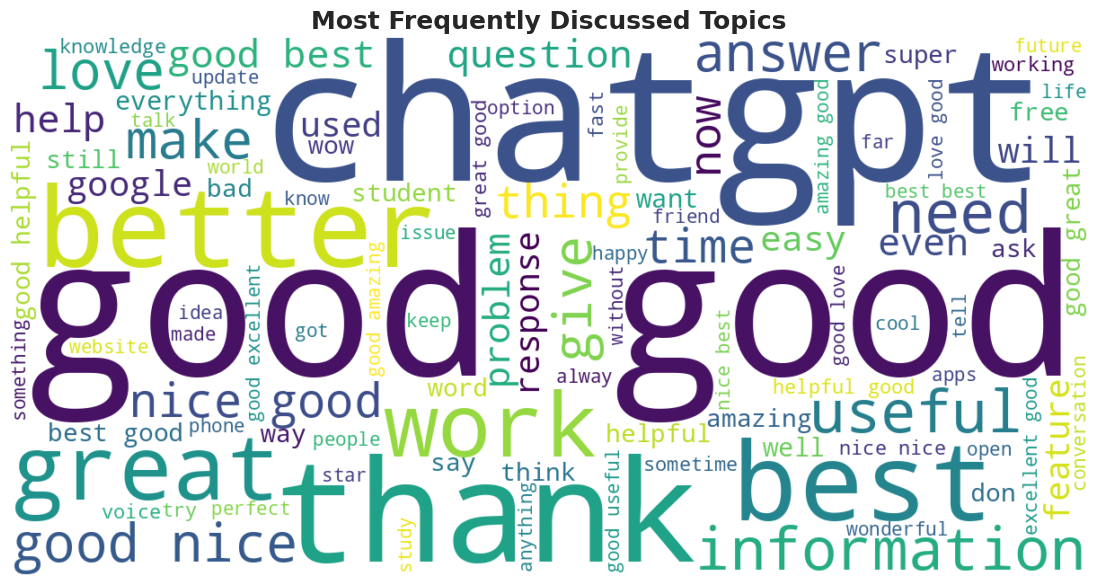

In [68]:
#Word Cloud
wordcloud_text = ' '.join(
    filtered_words
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(wordcloud_text)

plt.figure(figsize=(15, 7))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    'Most Frequently Discussed Topics',
    fontsize=18,
    fontweight='bold'
)

plt.show()

# 5. Sentiment Analysis

TextBlob is used to calculate:

- Polarity: strength and direction of sentiment
- Subjectivity: degree to which the review expresses an opinion

In [69]:
def calculate_polarity(text):

    if not text:
        return 0

    return TextBlob(
        text
    ).sentiment.polarity


df['sentiment_polarity'] = (
    df['clean_review']
    .apply(calculate_polarity)
)

In [70]:
#Subjectivity
def calculate_subjectivity(text):

    if not text:
        return 0

    return TextBlob(
        text
    ).sentiment.subjectivity


df['sentiment_subjectivity'] = (
    df['clean_review']
    .apply(calculate_subjectivity)
)

In [72]:
# Sentiment Categories
def categorize_sentiment(polarity):

    if polarity > 0.1:
        return 'Positive'

    elif polarity < -0.1:
        return 'Negative'

    else:
        return 'Neutral'


df['sentiment'] = (
    df['sentiment_polarity']
    .apply(categorize_sentiment)
)

In [73]:
#Sentiment Distribution
sentiment_counts = (
    df['sentiment']
    .value_counts()
)

print(sentiment_counts)

sentiment
Positive    144679
Neutral      43333
Negative      6204
Name: count, dtype: int64


In [74]:
sentiment_percentage = (
    df['sentiment']
    .value_counts(normalize=True)
    * 100
)

print(
    sentiment_percentage.round(2)
)

sentiment
Positive    74.49
Neutral     22.31
Negative     3.19
Name: proportion, dtype: float64


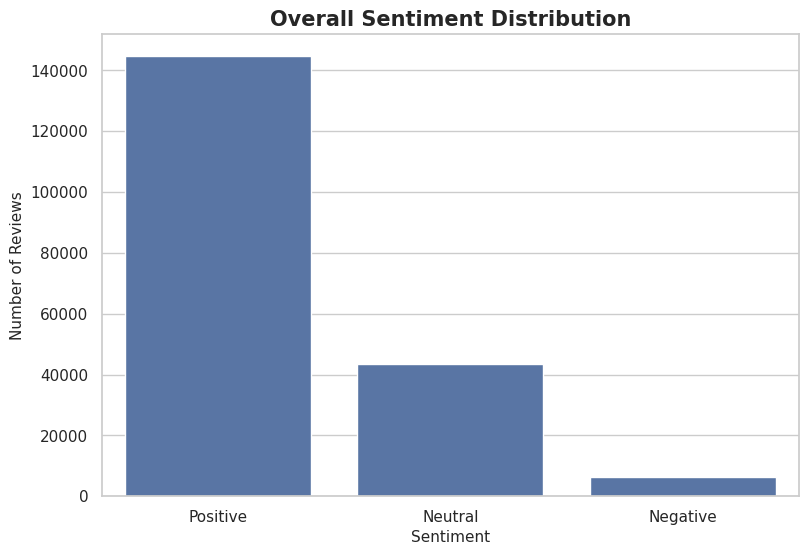

In [75]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='sentiment',
    order=[
        'Positive',
        'Neutral',
        'Negative'
    ]
)

plt.title(
    'Overall Sentiment Distribution',
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

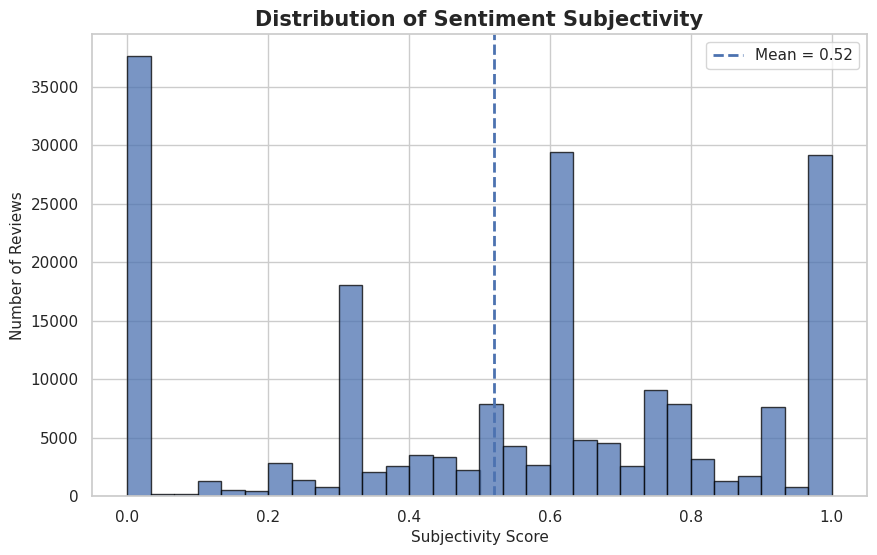

In [77]:
# Subjectivity Distribution
plt.figure(figsize=(10, 6))

plt.hist(
    df['sentiment_subjectivity'],
    bins=30,
    edgecolor='black',
    alpha=0.75
)

mean_subjectivity = (
    df['sentiment_subjectivity'].mean()
)

plt.axvline(
    mean_subjectivity,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_subjectivity:.2f}'
)

plt.title(
    'Distribution of Sentiment Subjectivity',
    fontweight='bold'
)

plt.xlabel('Subjectivity Score')
plt.ylabel('Number of Reviews')

plt.legend()

plt.show()

In [79]:
# Sentiment vs Rating

sentiment_rating = pd.crosstab(
    df['ratings'],
    df['sentiment'],
    normalize='index'
) * 100

sentiment_rating.round(2)

sentiment,Negative,Neutral,Positive
ratings,,,
1,25.30,48.19,26.52
2,15.72,41.00,43.28
3,7.11,31.22,61.67
4,2.42,21.52,76.06
5,1.03,19.44,79.53


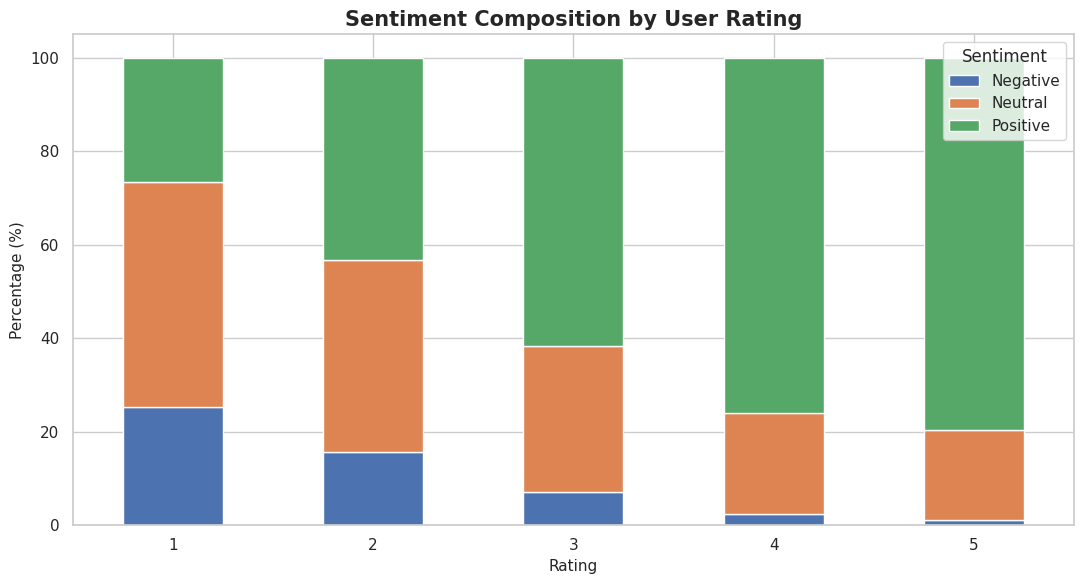

In [80]:
sentiment_rating.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    'Sentiment Composition by User Rating',
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=0)

plt.legend(
    title='Sentiment'
)

plt.tight_layout()
plt.show()

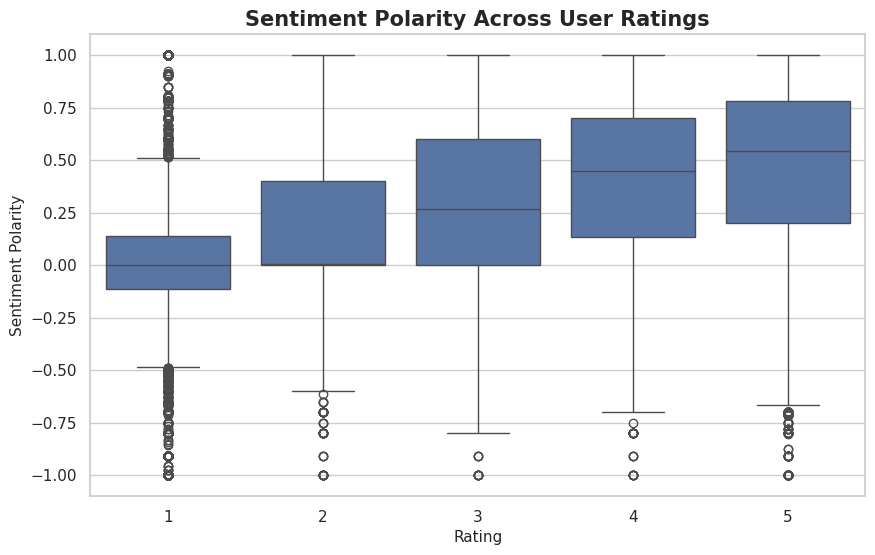

In [82]:
# Sentiment Polarity vs Rating
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='ratings',
    y='sentiment_polarity'
)

plt.title(
    'Sentiment Polarity Across User Ratings',
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Sentiment Polarity')

plt.show()

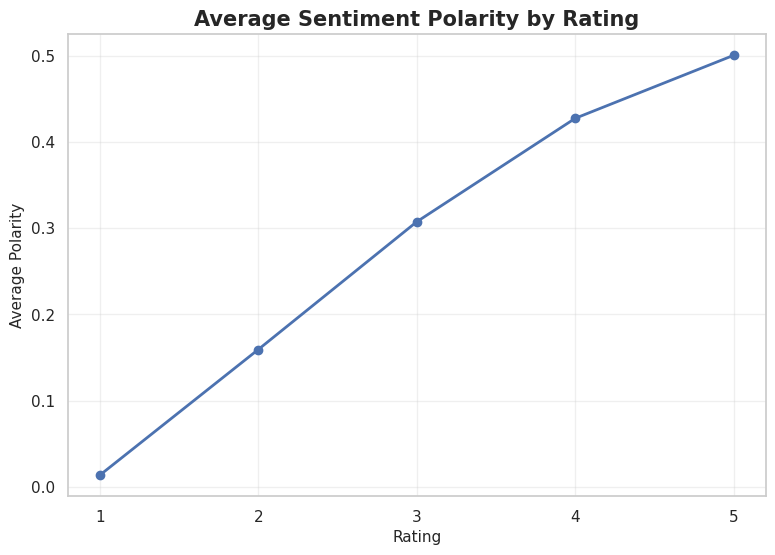

In [84]:
#Average Sentiment by Rating
average_sentiment_by_rating = (
    df.groupby('ratings')
    ['sentiment_polarity']
    .mean()
)

plt.figure(figsize=(9, 6))

plt.plot(
    average_sentiment_by_rating.index,
    average_sentiment_by_rating.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Average Sentiment Polarity by Rating',
    fontweight='bold'
)

plt.xlabel('Rating')
plt.ylabel('Average Polarity')

plt.xticks(range(1, 6))

plt.grid(alpha=0.3)

plt.show()

In [86]:
# Sentiment Over Time
monthly_sentiment = (
    df.groupby([
        df['review_date'].dt.to_period('M'),
        'sentiment'
    ])
    .size()
    .unstack(fill_value=0)
)

monthly_sentiment.index = (
    monthly_sentiment.index
    .to_timestamp()
)

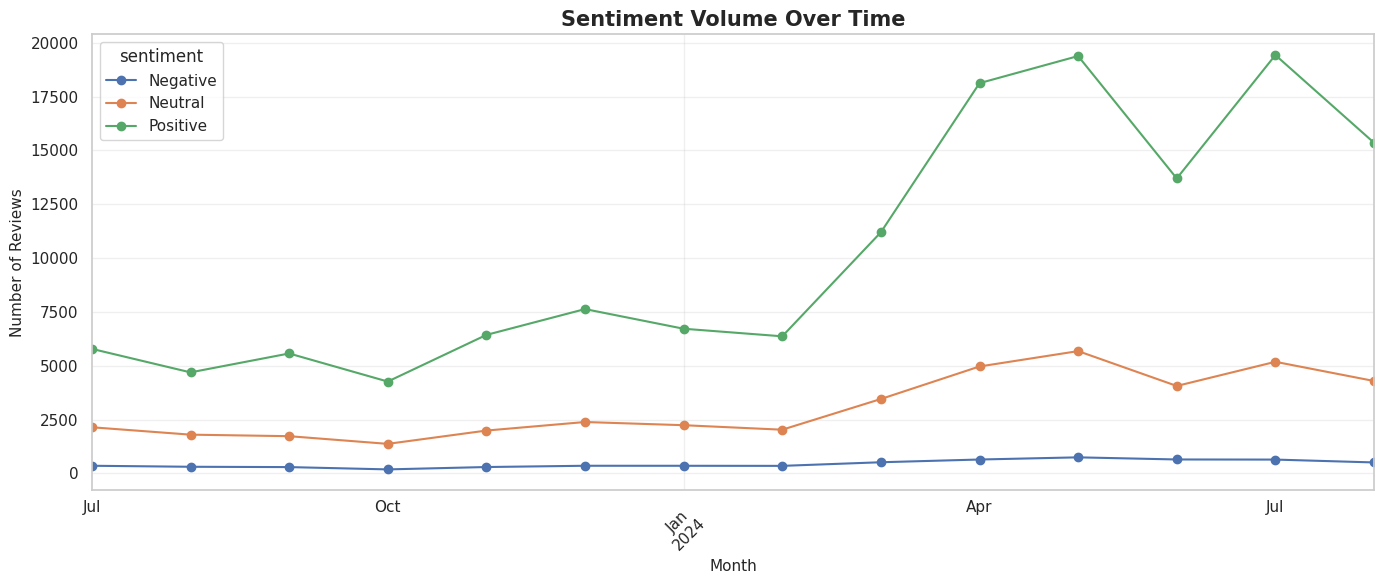

In [87]:
monthly_sentiment.plot(
    figsize=(14, 6),
    marker='o'
)

plt.title(
    'Sentiment Volume Over Time',
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
#Sentiment Percentage Over Time
monthly_sentiment_percentage = (
    pd.crosstab(
        df['review_date'].dt.to_period('M'),
        df['sentiment'],
        normalize='index'
    ) * 100
)

monthly_sentiment_percentage.index = (
    monthly_sentiment_percentage.index
    .to_timestamp()
)

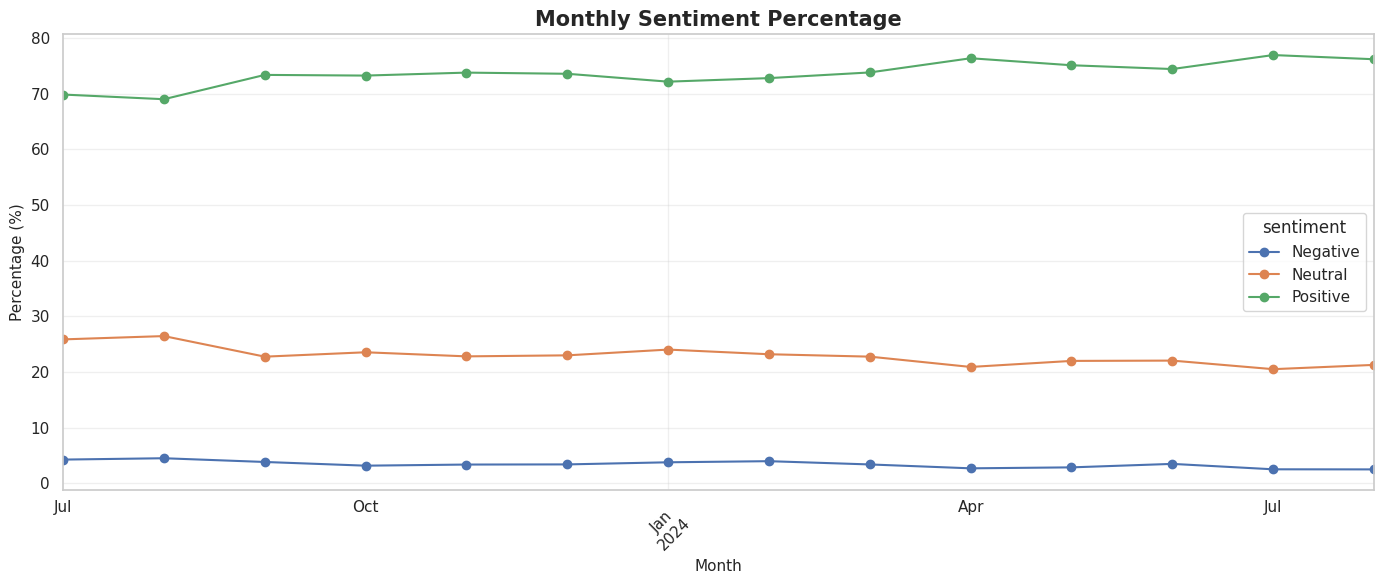

In [90]:
monthly_sentiment_percentage.plot(
    figsize=(14, 6),
    marker='o'
)

plt.title(
    'Monthly Sentiment Percentage',
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Positive Feature Analysis

Positive reviews are analyzed separately to identify the aspects of
ChatGPT that users appreciate most frequently.

In [91]:
positive_reviews = df[
    df['sentiment'] == 'Positive'
]['clean_review']

In [92]:
positive_words = []

for review in positive_reviews:

    positive_words.extend(
        review.split()
    )

positive_words = [
    word
    for word in positive_words
    if len(word) >= 3
    and word not in stop_words
]

positive_frequency = Counter(
    positive_words
)

positive_top_words = (
    positive_frequency
    .most_common(20)
)

positive_top_words

[('good', 38545),
 ('best', 18160),
 ('nice', 13669),
 ('great', 11726),
 ('helpful', 9225),
 ('amazing', 8577),
 ('love', 8436),
 ('chatgpt', 7783),
 ('useful', 7323),
 ('excellent', 6145),
 ('awesome', 5077),
 ('all', 4775),
 ('more', 4634),
 ('ever', 3792),
 ('help', 3245),
 ('better', 3227),
 ('work', 3162),
 ('information', 3144),
 ('application', 2876),
 ('easy', 2801)]

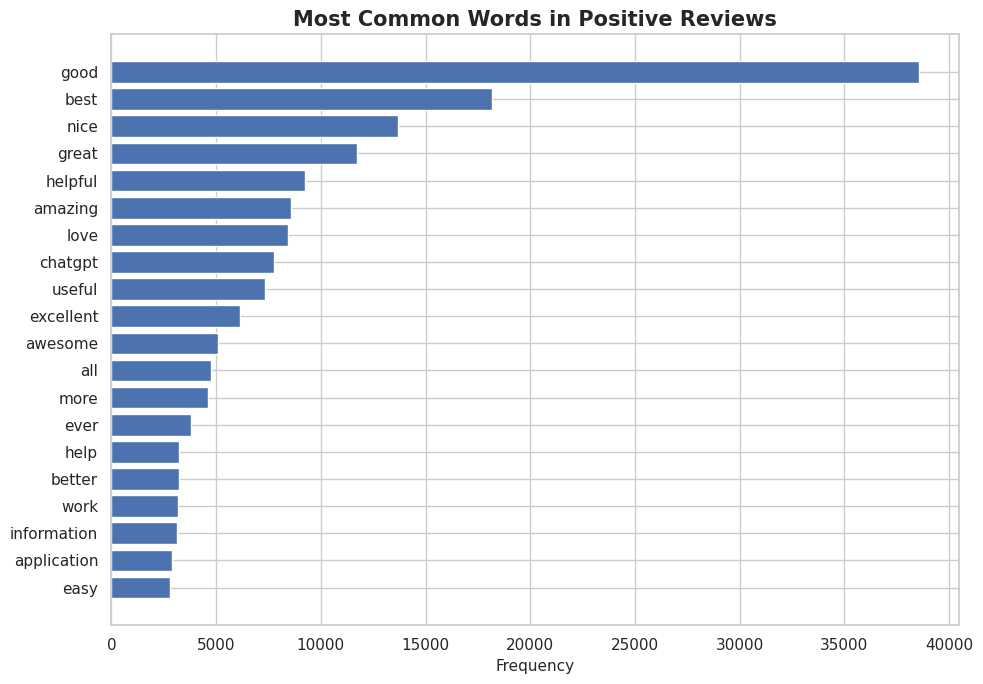

In [93]:
# Positive Word Visualization
words = [
    x[0]
    for x in positive_top_words
]

counts = [
    x[1]
    for x in positive_top_words
]

plt.figure(figsize=(10, 7))

plt.barh(
    words[::-1],
    counts[::-1]
)

plt.title(
    'Most Common Words in Positive Reviews',
    fontweight='bold'
)

plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

In [95]:
#Positive Bigrams
def get_bigrams(text):

    words = text.split()

    return [
        f'{words[i]} {words[i+1]}'
        for i in range(len(words)-1)
    ]


positive_bigrams = []

for review in positive_reviews:

    positive_bigrams.extend(
        get_bigrams(review)
    )


positive_bigram_counts = Counter(
    positive_bigrams
)

positive_bigram_top = (
    positive_bigram_counts
    .most_common(15)
)

positive_bigram_top

[('it s', 15031),
 ('this app', 10235),
 ('very good', 9248),
 ('it is', 7405),
 ('the best', 6759),
 ('good app', 5660),
 ('this is', 5417),
 ('very helpful', 5406),
 ('app is', 4898),
 ('best app', 4767),
 ('is very', 4638),
 ('i love', 4636),
 ('very useful', 4277),
 ('love it', 3647),
 ('very nice', 3472)]

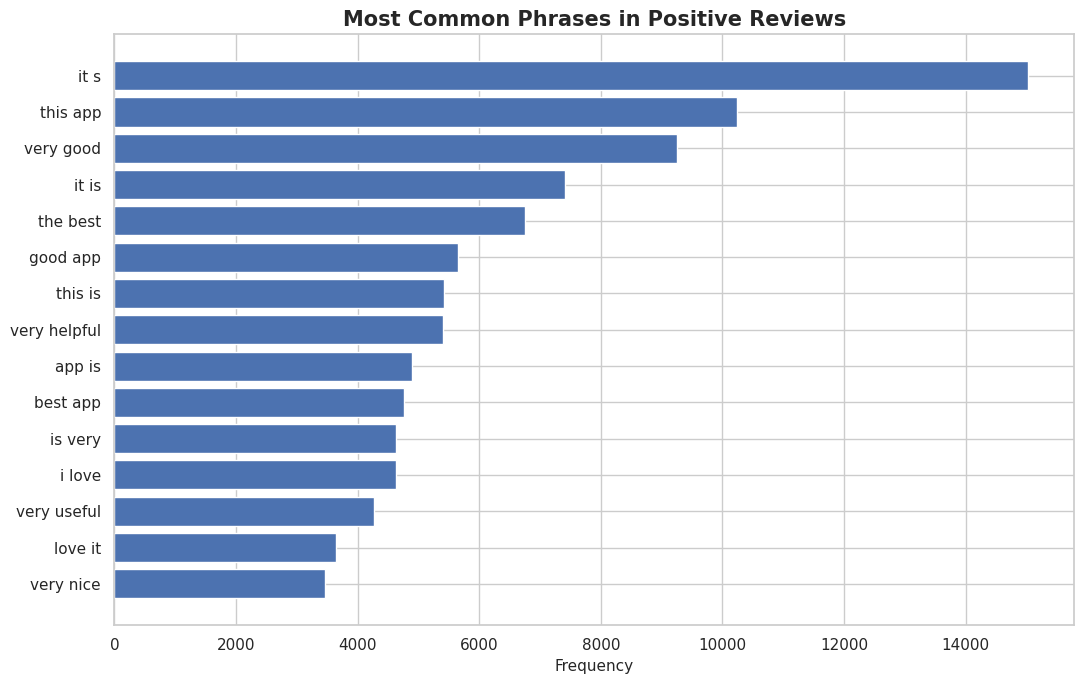

In [97]:
# Positive Bigram Visualization

phrases = [
    x[0]
    for x in positive_bigram_top
]

counts = [
    x[1]
    for x in positive_bigram_top
]

plt.figure(figsize=(11, 7))

plt.barh(
    phrases[::-1],
    counts[::-1]
)

plt.title(
    'Most Common Phrases in Positive Reviews',
    fontweight='bold'
)

plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

# 7. Critical Feedback Analysis

Negative reviews are analyzed to identify recurring problems,
limitations, and areas that may require improvement.

In [98]:
negative_reviews = df[
    df['sentiment'] == 'Negative'
]['clean_review']

In [100]:
negative_words = []

for review in negative_reviews:

    negative_words.extend(
        review.split()
    )

negative_words = [
    word
    for word in negative_words
    if len(word) >= 3
    and word not in stop_words
]

negative_frequency = Counter(
    negative_words
)

negative_top_words = (
    negative_frequency
    .most_common(20)
)

negative_top_words

[('bad', 764),
 ('wrong', 712),
 ('chatgpt', 462),
 ('when', 456),
 ('even', 385),
 ('answer', 385),
 ('time', 383),
 ('worst', 347),
 ('all', 338),
 ('don', 315),
 ('answers', 294),
 ('information', 287),
 ('give', 286),
 ('what', 280),
 ('doesn', 277),
 ('useless', 263),
 ('please', 262),
 ('because', 245),
 ('good', 244),
 ('there', 239)]

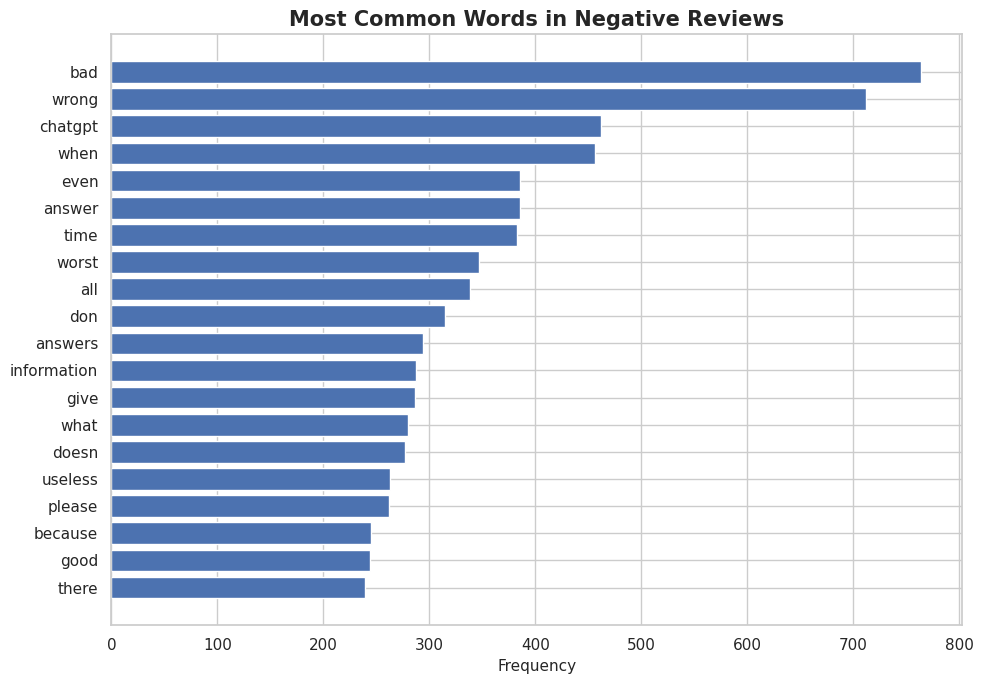

In [101]:
words = [
    x[0]
    for x in negative_top_words
]

counts = [
    x[1]
    for x in negative_top_words
]

plt.figure(figsize=(10, 7))

plt.barh(
    words[::-1],
    counts[::-1]
)

plt.title(
    'Most Common Words in Negative Reviews',
    fontweight='bold'
)

plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

In [102]:
issue_keywords = {

    'Performance': [
        'slow',
        'lag',
        'crash',
        'freeze',
        'bug',
        'glitch',
        'error'
    ],

    'Accuracy': [
        'wrong',
        'incorrect',
        'inaccurate',
        'mistake',
        'false'
    ],

    'Missing Features': [
        'missing',
        'feature',
        'option',
        'support',
        'update'
    ],

    'User Experience': [
        'difficult',
        'confusing',
        'interface',
        'design',
        'hard'
    ],

    'Pricing': [
        'price',
        'expensive',
        'cost',
        'subscription',
        'payment'
    ],

    'Access': [
        'login',
        'account',
        'access',
        'limit',
        'blocked'
    ]
}

In [103]:
issue_counts = {}

for category, keywords in issue_keywords.items():

    count = 0

    for review in negative_reviews:

        review = str(review)

        if any(
            keyword in review
            for keyword in keywords
        ):
            count += 1

    issue_counts[category] = count


issue_counts

{'Performance': 572,
 'Accuracy': 765,
 'Missing Features': 499,
 'User Experience': 203,
 'Pricing': 157,
 'Access': 489}

In [104]:
issue_counts = {}

for category, keywords in issue_keywords.items():

    count = 0

    for review in negative_reviews:

        review = str(review)

        if any(
            keyword in review
            for keyword in keywords
        ):
            count += 1

    issue_counts[category] = count


issue_counts

{'Performance': 572,
 'Accuracy': 765,
 'Missing Features': 499,
 'User Experience': 203,
 'Pricing': 157,
 'Access': 489}

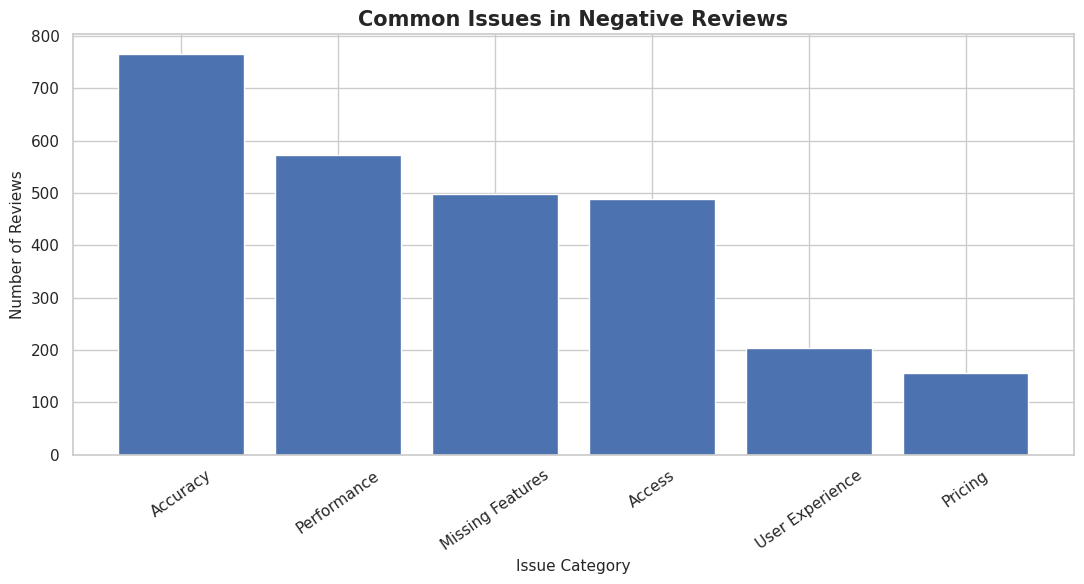

In [105]:
issue_series = (
    pd.Series(issue_counts)
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

plt.bar(
    issue_series.index,
    issue_series.values
)

plt.title(
    'Common Issues in Negative Reviews',
    fontweight='bold'
)

plt.xlabel('Issue Category')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

In [107]:
# Feature Requests
feature_request_keywords = [
    'add',
    'feature',
    'option',
    'support',
    'include',
    'allow',
    'wish',
    'need',
    'want',
    'please'
]

feature_request_count = 0

for review in df['clean_review']:

    if any(
        keyword in review
        for keyword in feature_request_keywords
    ):
        feature_request_count += 1

print(
    'Reviews containing feature-request terms:',
    feature_request_count
)

Reviews containing feature-request terms: 14393


# 8. Relationship Analysis

Correlation analysis is used to examine relationships between ratings,
review length, and sentiment characteristics.

In [108]:
numeric_columns = [
    'ratings',
    'review_length',
    'word_count',
    'sentiment_polarity',
    'sentiment_subjectivity'
]

correlation = (
    df[numeric_columns]
    .corr()
)

correlation.round(2)

,ratings,review_length,word_count,sentiment_polarity,sentiment_subjectivity
ratings,1.00,-0.19,-0.20,0.34,0.12
review_length,-0.19,1.00,0.99,-0.22,-0.03
word_count,-0.20,0.99,1.00,-0.22,-0.03
sentiment_polarity,0.34,-0.22,-0.22,1.00,0.55
sentiment_subjectivity,0.12,-0.03,-0.03,0.55,1.00


In [110]:
# Final KPI Summary
total_reviews = len(df)

average_rating = df['ratings'].mean()

five_star_percentage = (
    df['ratings'].eq(5).mean() * 100
)

one_star_percentage = (
    df['ratings'].eq(1).mean() * 100
)

positive_percentage = (
    df['sentiment'].eq('Positive').mean() * 100
)

negative_percentage = (
    df['sentiment'].eq('Negative').mean() * 100
)

neutral_percentage = (
    df['sentiment'].eq('Neutral').mean() * 100
)

average_subjectivity = (
    df['sentiment_subjectivity'].mean()
)

In [112]:
summary = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        'Average Rating',
        '5-Star Reviews',
        '5-Star Percentage',
        '1-Star Percentage',
        'Positive Sentiment',
        'Neutral Sentiment',
        'Negative Sentiment',
        'Average Subjectivity',
        'Average Review Words'
    ],

    'Value': [
        f'{total_reviews:,}',
        round(average_rating, 2),
        f'{(df["ratings"] == 5).sum():,}',
        f'{five_star_percentage:.2f}%',
        f'{one_star_percentage:.2f}%',
        f'{positive_percentage:.2f}%',
        f'{neutral_percentage:.2f}%',
        f'{negative_percentage:.2f}%',
        round(average_subjectivity, 3),
        round(df['word_count'].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Reviews,"194,216"
1,Average Rating,4.5
2,5-Star Reviews,"148,255"
3,5-Star Percentage,76.34%
4,1-Star Percentage,6.16%
5,Positive Sentiment,74.49%
6,Neutral Sentiment,22.31%
7,Negative Sentiment,3.19%
8,Average Subjectivity,0.521
9,Average Review Words,8.77


In [113]:
output_file = "ChatGPT_Review_Analysis_Final.csv"

df.to_csv(
    output_file,
    index=False
)

print(
    f"File saved successfully: {output_file}"
)

File saved successfully: ChatGPT_Review_Analysis_Final.csv


In [114]:
files.download(
    "ChatGPT_Review_Analysis_Final.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>